# 🌲 Ensemble Learning — Aula Prática
### Curso de Machine Learning

---

## 📋 Roteiro da Aula

| # | Tópico |
|---|--------|
| 1 | Contexto e Dataset |
| 2 | Pré-processamento |
| 3 | Bagging — Random Forest |
| 4 | Boosting — AdaBoost, Gradient Boosting, XGBoost |
| 5 | Stacking |
| 6 | Voting |
| 7 | Comparação Final |

---

> **Dataset desta aula:** Qualidade de vinhos tintos  
> - **Regressão:** prever a pontuação de qualidade (0–10)  
> - **Classificação:** prever se o vinho é *ruim* (≤5), *médio* (6) ou *bom* (≥7)

---
## 0. Instalação e Imports

In [1]:
# Instalações extras (XGBoost já vem no Colab)
!pip install xgboost lightgbm --quiet

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos base
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier

# Ensembles
from sklearn.ensemble import (
    BaggingClassifier, BaggingRegressor,
    RandomForestClassifier, RandomForestRegressor,
    AdaBoostClassifier, AdaBoostRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    StackingClassifier, StackingRegressor,
    VotingClassifier, VotingRegressor,
    ExtraTreesClassifier
)
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

# Métricas
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

# Estilo dos gráficos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
np.random.seed(SEED)
print('✅ Imports concluídos!')

✅ Imports concluídos!


---
## 1. Dataset — Qualidade de Vinhos Tintos 🍷

### Contexto
Uma vinícola quer **automatizar o controle de qualidade**. Enólogos avaliaram centenas de amostras e atribuíram notas. Com dados físico-químicos do laboratório, queremos:

- **Prever a nota exata** → Regressão
- **Classificar a categoria** → Classificação (Ruim / Médio / Bom)

### Atributos do Dataset

| Coluna | Descrição | Unidade |
|--------|-----------|--------|
| `acidez_fixa` | Ácidos não voláteis | g/L |
| `acidez_volatil` | Ácido acético (vinagre) | g/L |
| `acido_citrico` | Frescor e sabor | g/L |
| `acucar_residual` | Açúcar após fermentação | g/L |
| `cloretos` | Teor de sal | g/L |
| `dioxido_enxofre_livre` | SO₂ livre (conservante) | mg/L |
| `dioxido_enxofre_total` | SO₂ total | mg/L |
| `densidade` | Densidade da amostra | g/cm³ |
| `ph` | Acidez geral | — |
| `sulfatos` | Conservante e antimicrobiano | g/L |
| `alcool` | Teor alcoólico | % vol |
| `qualidade` | ⭐ Nota do enólogo (0–10) | — |

In [4]:
df=pd.read_csv('vinhos.csv')

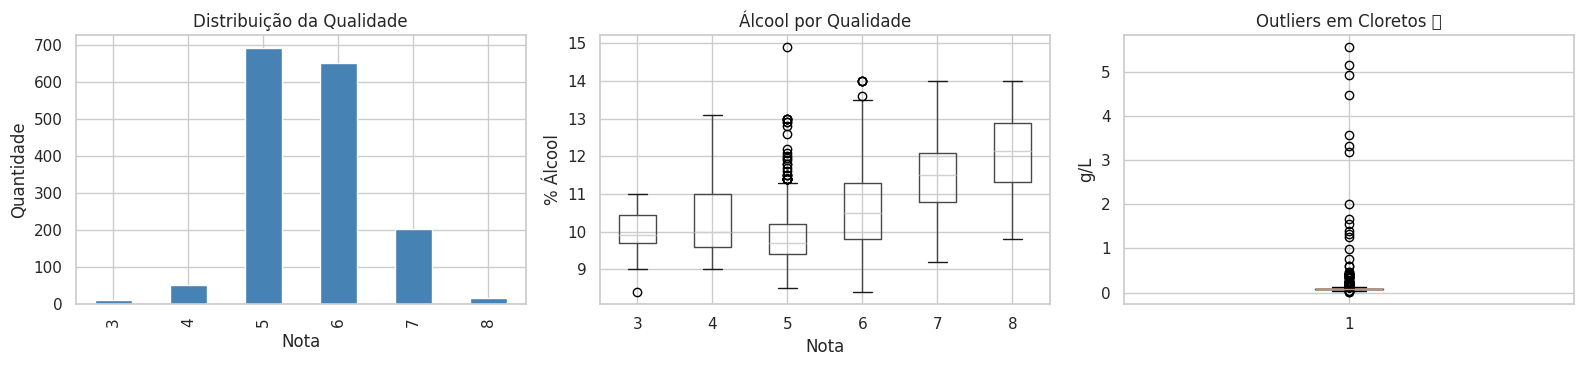


📊 Estatísticas descritivas:


,acidez_fixa,acidez_volatil,acido_citrico,acucar_residual,cloretos,dioxido_enxofre_livre,dioxido_enxofre_total,densidade,ph,sulfatos,alcool,qualidade,temp_fermentacao
count,1629.000,1629.000,1548.000,1548.000,1629.000,1629.000,1629.000,1629.000,1629.000,1548.000,1629.000,1629.000,1629.000
mean,8.320,0.529,0.272,2.549,0.112,15.903,46.646,0.997,3.311,0.658,10.423,5.635,20.170
std,1.743,0.179,0.196,1.422,0.301,10.472,33.073,0.002,0.154,0.171,1.063,0.807,5.120
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000,2.159
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000,16.852
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000,20.298
75%,9.200,0.640,0.430,2.600,0.091,21.000,63.000,0.998,3.400,0.730,11.100,6.000,23.731
max,15.900,1.580,1.000,15.500,5.563,72.000,289.000,1.004,4.010,2.000,14.900,8.000,36.273


In [5]:
# Análise exploratória rápida
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribuição da qualidade
df['qualidade'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição da Qualidade')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Quantidade')

# Boxplot de álcool vs qualidade
df.boxplot(column='alcool', by='qualidade', ax=axes[1])
axes[1].set_title('Álcool por Qualidade')
axes[1].set_xlabel('Nota')
axes[1].set_ylabel('% Álcool')
plt.sca(axes[1]); plt.title('Álcool por Qualidade')

# Outliers nos cloretos
axes[2].boxplot(df['cloretos'].dropna())
axes[2].set_title('Outliers em Cloretos 🚨')
axes[2].set_ylabel('g/L')

plt.suptitle('')
plt.tight_layout()
plt.show()

print('\n📊 Estatísticas descritivas:')
df.describe().round(3)

---
## 2. Pré-processamento 🛠️

### Etapas:
1. Remover duplicatas
2. Tratar outliers (IQR)
3. Imputar valores ausentes
4. Codificar variável categórica (`lote`)
5. Normalizar features numéricas
6. Criar variável-alvo para classificação

In [7]:
df_clean = df.copy()

# ── 1. Remover duplicatas ──────────────────────────────────
antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'✅ Duplicatas removidas: {antes - len(df_clean)}')

# ── 2. Tratar outliers via IQR (apenas em cloretos) ────────
col = 'cloretos'
Q1 = df_clean[col].quantile(0.25)
Q3 = df_clean[col].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 3 * IQR  # critério mais tolerante
outliers = (df_clean[col] > limite_sup).sum()
df_clean[col] = df_clean[col].clip(upper=limite_sup)
print(f'✅ Outliers tratados em "{col}": {outliers}')

# ── 3. Imputar valores ausentes ────────────────────────────
colunas_num = ['acido_citrico', 'sulfatos', 'acucar_residual']
for col in colunas_num:
    mediana = df_clean[col].median()
    faltantes = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(mediana)
    print(f'✅ "{col}": {faltantes} valores imputados com mediana={mediana:.3f}')

# ── 4. Codificar lote (One-Hot Encoding) ───────────────────
df_clean = pd.get_dummies(df_clean, columns=['lote'], drop_first=False)
print(f'✅ One-Hot Encoding aplicado em "lote"')

# ── 5. Criar target de classificação ──────────────────────
def categorizar_qualidade(nota):
    if nota <= 5:
        return 0  # Ruim
    elif nota == 6:
        return 1  # Médio
    else:
        return 2  # Bom

df_clean['categoria'] = df_clean['qualidade'].apply(categorizar_qualidade)
rotulos = {0: 'Ruim (≤5)', 1: 'Médio (6)', 2: 'Bom (≥7)'}

print(f'\n📊 Distribuição das categorias:')
print(df_clean['categoria'].map(rotulos).value_counts())

# ── 6. Separar features e targets ─────────────────────────
feature_cols = [c for c in df_clean.columns if c not in ['qualidade', 'categoria']]

X = df_clean[feature_cols]
y_reg = df_clean['qualidade']          # para regressão
y_clf = df_clean['categoria']          # para classificação

# ── 7. Dividir treino / teste ──────────────────────────────
X_train, X_test, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=SEED)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf)

# ── 8. Normalizar (StandardScaler) ────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

X_train_cs = scaler.fit_transform(X_train_c)
X_test_cs  = scaler.transform(X_test_c)

print(f'\n✅ Pré-processamento concluído!')
print(f'   Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'   Features: {X_train.shape[1]}')

✅ Duplicatas removidas: 0
✅ Outliers tratados em "cloretos": 81
✅ "acido_citrico": 81 valores imputados com mediana=0.260
✅ "sulfatos": 81 valores imputados com mediana=0.620
✅ "acucar_residual": 81 valores imputados com mediana=2.200
✅ One-Hot Encoding aplicado em "lote"

📊 Distribuição das categorias:
categoria
Ruim (≤5)    757
Médio (6)    652
Bom (≥7)     220
Name: count, dtype: int64

✅ Pré-processamento concluído!
   Treino: 1303 amostras | Teste: 326 amostras
   Features: 16


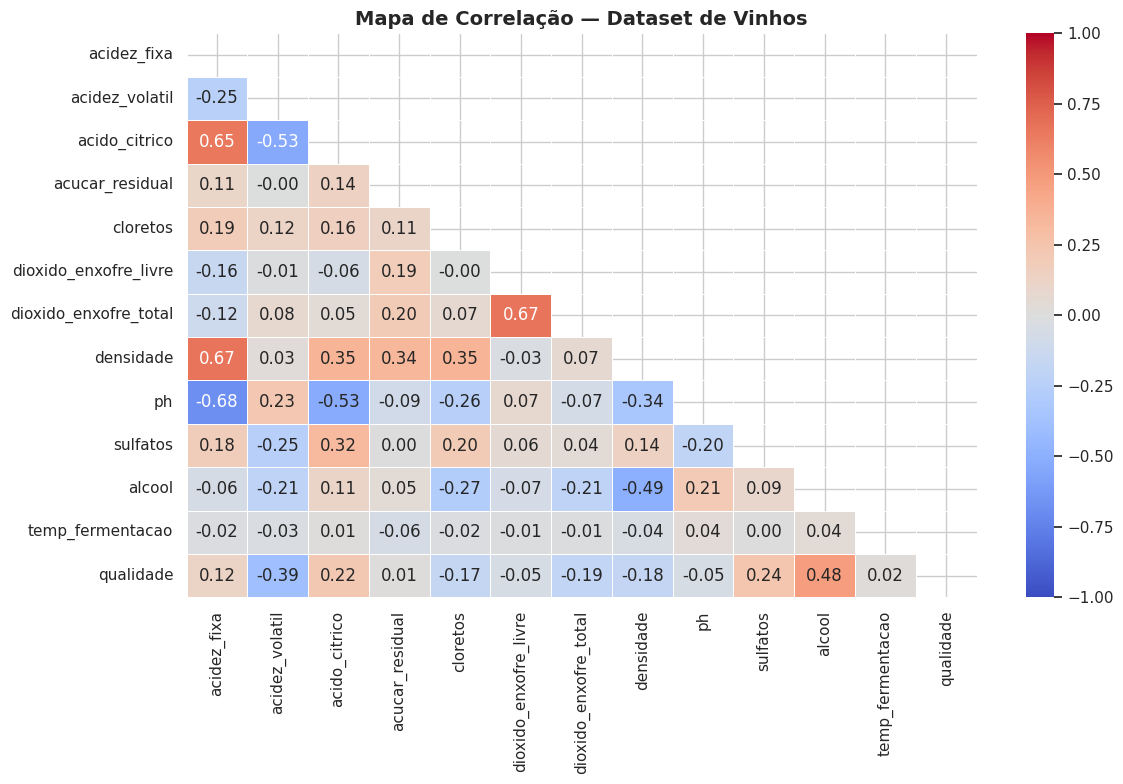

In [8]:
# Correlação das features com a qualidade
num_cols = ['acidez_fixa','acidez_volatil','acido_citrico','acucar_residual',
            'cloretos','dioxido_enxofre_livre','dioxido_enxofre_total',
            'densidade','ph','sulfatos','alcool','temp_fermentacao','qualidade']

plt.figure(figsize=(12, 8))
corr = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Correlação — Dataset de Vinhos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Bagging 🎒

### Conceito
**B**ootstrap **Agg**regat**ing** — treina vários modelos em subconjuntos aleatórios (com reposição) e combina suas previsões.

```
Dataset original
      │
   ┌──┴──┬──────┬──────┐
  B₁    B₂    B₃    B₄   ← bootstraps
  │     │     │     │
 M₁    M₂    M₃    M₄   ← modelos independentes
  └──────┴──────┴──────┘
          │
       Votação / Média
```

**Vantagem:** Reduz **variância** — ótimo quando o modelo base é instável (ex: árvores profundas).

In [9]:
# ────────────────────────────────────────────────────────────
#  3.1 Bagging — Classificação
# ────────────────────────────────────────────────────────────
print('=' * 55)
print('  BAGGING — Classificação')
print('=' * 55)

# Modelo base — árvore sem poda (alta variância)
arvore_base = DecisionTreeClassifier(
    random_state=SEED # Semente para reprodutibilidade dos resultados aleatórios
)
arvore_base.fit(X_train_cs, y_train_c)
acc_arvore = accuracy_score(y_test_c, arvore_base.predict(X_test_cs))
print(f'\nÁrvore simples     : {acc_arvore:.4f}')

# BaggingClassifier
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=SEED), # O modelo base a ser usado (neste caso, uma Árvore de Decisão)
    n_estimators=100, # Número de estimadores (modelos base) no ensemble
    max_samples=0.8, # Fração do número de amostras do dataset de treino para treinar cada estimador (bootstrap)
    max_features=0.8, # Fração do número de features para treinar cada estimador
    random_state=SEED, # Semente para reprodutibilidade
    n_jobs=-1 # Usa todos os cores do processador para paralelizar o treinamento
)
bagging_clf.fit(X_train_cs, y_train_c)
acc_bag = accuracy_score(y_test_c, bagging_clf.predict(X_test_cs))
print(f'Bagging (100 est.) : {acc_bag:.4f}')

# Random Forest (bagging especializado)
rf_clf = RandomForestClassifier(
    n_estimators=100, # Número de árvores na floresta
    random_state=SEED, # Semente para reprodutibilidade
    n_jobs=-1 # Usa todos os cores do processador para paralelizar o treinamento
)
rf_clf.fit(X_train_cs, y_train_c)
acc_rf = accuracy_score(y_test_c, rf_clf.predict(X_test_cs))
print(f'Random Forest      : {acc_rf:.4f}')

# Extra Trees
et_clf = ExtraTreesClassifier(
    n_estimators=100, # Número de árvores na floresta
    random_state=SEED, # Semente para reprodutibilidade
    n_jobs=-1 # Usa todos os cores do processador para paralelizar o treinamento
)
et_clf.fit(X_train_cs, y_train_c)
acc_et = accuracy_score(y_test_c, et_clf.predict(X_test_cs))
print(f'Extra Trees        : {acc_et:.4f}')

print('\n📋 Relatório — Random Forest:')
print(classification_report(
    y_test_c, rf_clf.predict(X_test_cs),
    target_names=['Ruim', 'Médio', 'Bom']
))

  BAGGING — Classificação

Árvore simples     : 0.5736
Bagging (100 est.) : 0.7239
Random Forest      : 0.7393
Extra Trees        : 0.7117

📋 Relatório — Random Forest:
              precision    recall  f1-score   support

        Ruim       0.80      0.75      0.77       152
       Médio       0.67      0.78      0.72       130
         Bom       0.79      0.59      0.68        44

    accuracy                           0.74       326
   macro avg       0.75      0.71      0.72       326
weighted avg       0.75      0.74      0.74       326



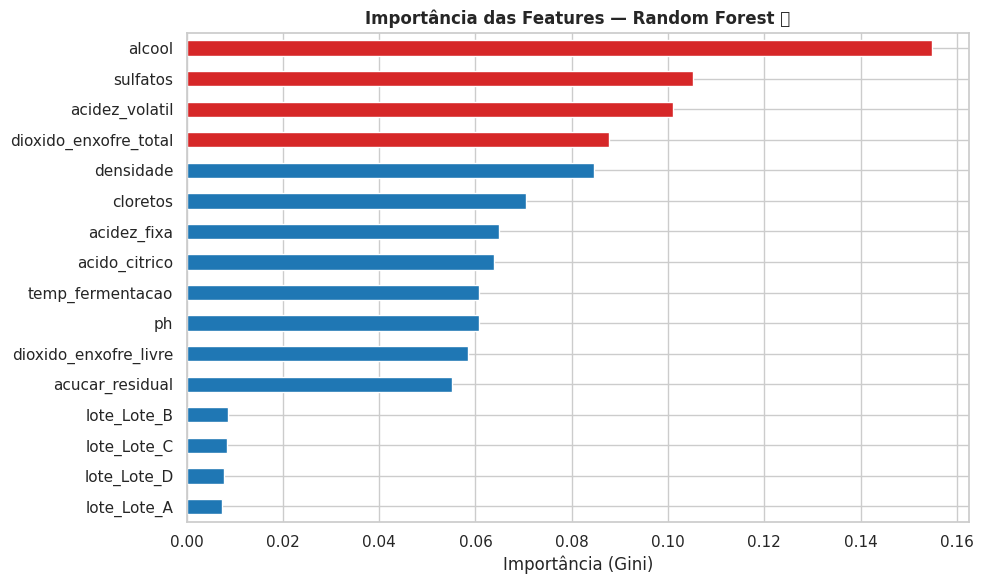

In [10]:
# Importância das features — Random Forest
importancias = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#d62728' if v > importancias.quantile(0.75) else '#1f77b4' for v in importancias]
importancias.plot(kind='barh', color=colors)
plt.title('Importância das Features — Random Forest 🌲', fontweight='bold')
plt.xlabel('Importância (Gini)')
plt.tight_layout()
plt.show()

  BAGGING — Regressão

Random Forest Regressor:
  RMSE : 0.5968
  MAE  : 0.4386
  R²   : 0.4368


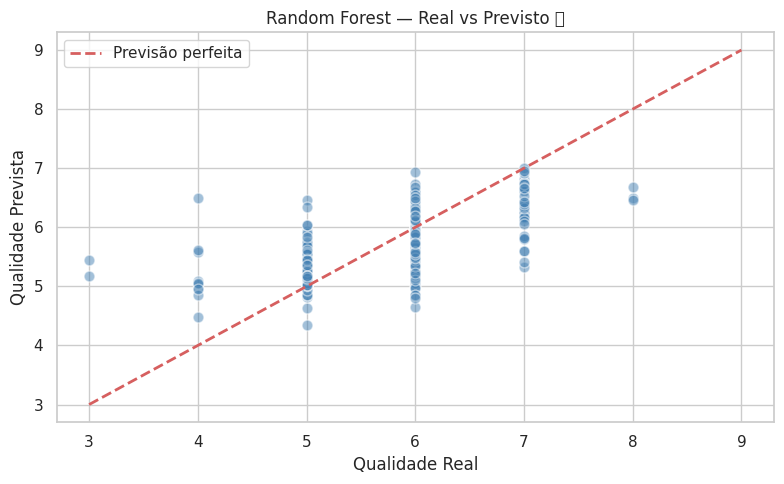

In [11]:
# ────────────────────────────────────────────────────────────
#  3.2 Bagging — Regressão
# ────────────────────────────────────────────────────────────
print('=' * 55)
print('  BAGGING — Regressão')
print('=' * 55)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_reg.fit(X_train_s, y_train_r)
pred_rf = rf_reg.predict(X_test_s)

print(f'\nRandom Forest Regressor:')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_test_r, pred_rf)):.4f}')
print(f'  MAE  : {mean_absolute_error(y_test_r, pred_rf):.4f}')
print(f'  R²   : {r2_score(y_test_r, pred_rf):.4f}')

# Gráfico real vs previsto
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, pred_rf, alpha=0.5, color='steelblue', edgecolors='white', s=60)
plt.plot([3, 9], [3, 9], 'r--', lw=2, label='Previsão perfeita')
plt.xlabel('Qualidade Real')
plt.ylabel('Qualidade Prevista')
plt.title('Random Forest — Real vs Previsto 🍷')
plt.legend()
plt.tight_layout()
plt.show()

---
## 4. Boosting ⚡

### Conceito
Treina modelos **sequencialmente**, cada um focando nos erros do anterior.

```
M₁ → erros(M₁) → M₂ → erros(M₁+M₂) → M₃ → ... → Mₙ
Previsão final = combinação ponderada de M₁ + M₂ + ... + Mₙ
```

**Vantagem:** Reduz **viés** — ótimo com modelos fracos (shallow trees).  
**Cuidado:** Pode sobreajustar se n_estimators muito alto sem regularização.

### Algoritmos:
| Algoritmo | Mecanismo | Destaque |
|-----------|-----------|----------|
| AdaBoost | Pesa os exemplos mal classificados | Simples e interpretável |
| Gradient Boosting | Otimiza gradiente da loss | Robusto e flexível |
| XGBoost | GB com regularização L1/L2 | Vencedor de competições |
| LightGBM | GB por histograma | Muito rápido em dados grandes |

AdaBoost — Classificação
----------------------------------------
Acurácia: 0.6196


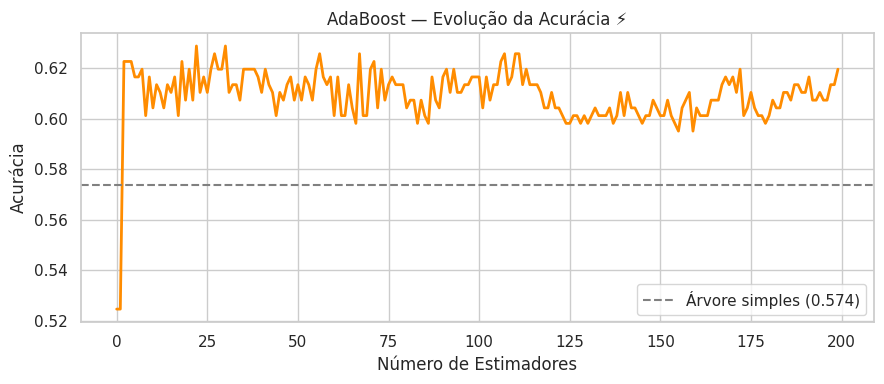

In [12]:
# ────────────────────────────────────────────────────────────
#  4.1 AdaBoost — Classificação
# ────────────────────────────────────────────────────────────
print('AdaBoost — Classificação')
print('-' * 40)

ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=SEED),  # modelo fraco
    n_estimators=200,
    learning_rate=0.5,
    random_state=SEED
)
ada_clf.fit(X_train_cs, y_train_c)
acc_ada = accuracy_score(y_test_c, ada_clf.predict(X_test_cs))
print(f'Acurácia: {acc_ada:.4f}')

# Curva de aprendizado — acurácia por n_estimators
accs = []
for pred_proba in ada_clf.staged_predict(X_test_cs):
    accs.append(accuracy_score(y_test_c, pred_proba))

plt.figure(figsize=(9, 4))
plt.plot(accs, color='darkorange', lw=2)
plt.axhline(acc_arvore, ls='--', color='gray', label=f'Árvore simples ({acc_arvore:.3f})')
plt.xlabel('Número de Estimadores')
plt.ylabel('Acurácia')
plt.title('AdaBoost — Evolução da Acurácia ⚡')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import time

# ────────────────────────────────────────────────────────────
#  4.2 Gradient Boosting — Classificação
# ────────────────────────────────────────────────────────────
print('Gradient Boosting — Classificação')
print('-' * 40)

gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=SEED
)

start_time_gb = time.time()
gb_clf.fit(X_train_cs, y_train_c)
end_time_gb = time.time()

acc_gb = accuracy_score(y_test_c, gb_clf.predict(X_test_cs))
print(f'Acurácia: {acc_gb:.4f}')
print(f'Tempo de execução: {end_time_gb - start_time_gb:.4f} segundos')

# ────────────────────────────────────────────────────────────
#  4.3 XGBoost — Classificação
# ────────────────────────────────────────────────────────────
print('\nXGBoost — Classificação')
print('-' * 40)

xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=SEED,
    verbosity=0
)

start_time_xgb = time.time()
xgb_clf.fit(X_train_cs, y_train_c)
end_time_xgb = time.time()

acc_xgb = accuracy_score(y_test_c, xgb_clf.predict(X_test_cs))
print(f'Acurácia: {acc_xgb:.4f}')
print(f'Tempo de execução: {end_time_xgb - start_time_xgb:.4f} segundos')

# ────────────────────────────────────────────────────────────
#  4.4 LightGBM — Classificação
# ────────────────────────────────────────────────────────────
print('\nLightGBM — Classificação')
print('-' * 40)

lgbm_clf = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=SEED,
    verbose=-1
)

start_time_lgbm = time.time()
lgbm_clf.fit(X_train_cs, y_train_c)
end_time_lgbm = time.time()

acc_lgbm = accuracy_score(y_test_c, lgbm_clf.predict(X_test_cs))
print(f'Acurácia: {acc_lgbm:.4f}')
print(f'Tempo de execução: {end_time_lgbm - start_time_lgbm:.4f} segundos')

Gradient Boosting — Classificação
----------------------------------------
Acurácia: 0.6994
Tempo de execução: 8.2532 segundos

XGBoost — Classificação
----------------------------------------
Acurácia: 0.7025
Tempo de execução: 1.0921 segundos

LightGBM — Classificação
----------------------------------------
Acurácia: 0.7025
Tempo de execução: 0.3269 segundos


In [16]:
# ────────────────────────────────────────────────────────────
#  4.5 Boosting — Regressão
# ────────────────────────────────────────────────────────────
print('Boosting — Regressão')
print('=' * 55)

resultados_reg = {}

modelos_reg = {
    'AdaBoost': AdaBoostRegressor(n_estimators=200, learning_rate=0.5, random_state=SEED),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                    max_depth=4, subsample=0.8, random_state=SEED),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                            subsample=0.8, colsample_bytree=0.8, random_state=SEED, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                              subsample=0.8, random_state=SEED, verbose=-1)
}

for nome, modelo in modelos_reg.items():
    modelo.fit(X_train_s, y_train_r)
    pred = modelo.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test_r, pred))
    r2   = r2_score(y_test_r, pred)
    resultados_reg[nome] = {'RMSE': rmse, 'R²': r2}
    print(f'{nome:<22} RMSE={rmse:.4f}  R²={r2:.4f}')

print('\n✅ Boosting de regressão concluído!')

Boosting — Regressão
AdaBoost               RMSE=0.6186  R²=0.3948
Gradient Boosting      RMSE=0.6231  R²=0.3860
XGBoost                RMSE=0.6213  R²=0.3895
LightGBM               RMSE=0.6295  R²=0.3734

✅ Boosting de regressão concluído!


---
## 5. Stacking 🏗️

### Conceito
Treina modelos de **nível 0** (base), e usa as previsões deles como features para um **meta-modelo** (nível 1).

```
                  ┌─── Random Forest ───┐
                  │                     │
Dataset ──────────┤─── XGBoost ─────────┼──▶ Meta-modelo ──▶ Previsão final
                  │                     │      (LR / Ridge)
                  └─── KNN ─────────────┘
```

**Chave:** O meta-modelo aprende a combinar os pontos fortes de cada base.

In [17]:
# ────────────────────────────────────────────────────────────
#  5.1 Stacking — Classificação
# ────────────────────────────────────────────────────────────
print('Stacking — Classificação')
print('=' * 55)

estimadores_base = [
    ('rf',   RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ('xgb',  XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=SEED,
                           use_label_encoder=False, eval_metric='mlogloss', verbosity=0)),
    ('knn',  KNeighborsClassifier(n_neighbors=7, n_jobs=-1)),
]

meta_modelo = LogisticRegression(max_iter=500, random_state=SEED)

stacking_clf = StackingClassifier(
    estimators=estimadores_base,
    final_estimator=meta_modelo,
    cv=5,
    passthrough=False,  # True = passa features originais ao meta-modelo também
    n_jobs=-1
)

stacking_clf.fit(X_train_cs, y_train_c)
acc_stk = accuracy_score(y_test_c, stacking_clf.predict(X_test_cs))
print(f'Acurácia do Stacking: {acc_stk:.4f}')

# Comparando com os modelos base
print(f'  └─ RF   base: {acc_rf:.4f}')
print(f'  └─ XGB  base: {acc_xgb:.4f}')
print(f'  └─ LGBM base: {acc_lgbm:.4f}')

Stacking — Classificação
Acurácia do Stacking: 0.7393
  └─ RF   base: 0.7393
  └─ XGB  base: 0.7025
  └─ LGBM base: 0.7025


In [18]:
# ────────────────────────────────────────────────────────────
#  5.2 Stacking — Regressão
# ────────────────────────────────────────────────────────────
print('Stacking — Regressão')
print('=' * 55)

estimadores_base_r = [
    ('rf',   RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ('xgb',  XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=SEED, verbosity=0)),
    ('gb',   GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=SEED)),
]

meta_modelo_r = Ridge(alpha=1.0)

stacking_reg = StackingRegressor(
    estimators=estimadores_base_r,
    final_estimator=meta_modelo_r,
    cv=5,
    n_jobs=-1
)

stacking_reg.fit(X_train_s, y_train_r)
pred_stk = stacking_reg.predict(X_test_s)

rmse_stk = np.sqrt(mean_squared_error(y_test_r, pred_stk))
r2_stk   = r2_score(y_test_r, pred_stk)
print(f'Stacking Regressor:')
print(f'  RMSE : {rmse_stk:.4f}')
print(f'  R²   : {r2_stk:.4f}')

Stacking — Regressão
Stacking Regressor:
  RMSE : 0.5989
  R²   : 0.4328


---
## 6. Voting 🗳️

### Conceito
Combina as previsões de vários modelos por **votação** (classificação) ou **média** (regressão).

- **Hard Voting:** decide pela classe mais votada
- **Soft Voting:** decide pela maior probabilidade média

```
        RF   →  [0.7, 0.2, 0.1]
        XGB  →  [0.6, 0.3, 0.1]   ─▶  média  ─▶  classe 0 ✅
        LGBM →  [0.8, 0.1, 0.1]
```

In [19]:
# ────────────────────────────────────────────────────────────
#  6.1 Voting — Classificação
# ────────────────────────────────────────────────────────────
print('Voting — Classificação')
print('=' * 55)

voting_hard = VotingClassifier(
    estimators=[
        ('rf',   RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)),
        ('xgb',  XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=SEED,
                               use_label_encoder=False, eval_metric='mlogloss', verbosity=0)),
        ('lgbm', LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=SEED, verbose=-1)),
    ],
    voting='hard',
    n_jobs=-1
)
voting_hard.fit(X_train_cs, y_train_c)
acc_vh = accuracy_score(y_test_c, voting_hard.predict(X_test_cs))
print(f'Hard Voting: {acc_vh:.4f}')

voting_soft = VotingClassifier(
    estimators=[
        ('rf',   RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)),
        ('xgb',  XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=SEED,
                               use_label_encoder=False, eval_metric='mlogloss', verbosity=0)),
        ('lgbm', LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=SEED, verbose=-1)),
    ],
    voting='soft',
    n_jobs=-1
)
voting_soft.fit(X_train_cs, y_train_c)
acc_vs = accuracy_score(y_test_c, voting_soft.predict(X_test_cs))
print(f'Soft Voting: {acc_vs:.4f}')

Voting — Classificação
Hard Voting: 0.7025
Soft Voting: 0.7117


In [20]:
# ────────────────────────────────────────────────────────────
#  6.2 Voting — Regressão
# ────────────────────────────────────────────────────────────
print('Voting — Regressão')
print('=' * 55)

voting_reg = VotingRegressor(
    estimators=[
        ('rf',   RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)),
        ('xgb',  XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=SEED, verbosity=0)),
        ('lgbm', LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=SEED, verbose=-1)),
    ],
    n_jobs=-1
)
voting_reg.fit(X_train_s, y_train_r)
pred_vr = voting_reg.predict(X_test_s)

rmse_vr = np.sqrt(mean_squared_error(y_test_r, pred_vr))
r2_vr   = r2_score(y_test_r, pred_vr)
print(f'Voting Regressor:')
print(f'  RMSE : {rmse_vr:.4f}')
print(f'  R²   : {r2_vr:.4f}')

Voting — Regressão
Voting Regressor:
  RMSE : 0.6033
  R²   : 0.4245


---
## 7. Comparação Final 🏆

### Consolidando todos os resultados

🏆 Ranking — Classificação (por Acurácia):
               Modelo Categoria  Acurácia
1       Random Forest   Bagging  0.739264
2            Stacking  Stacking  0.739264
3             Bagging   Bagging  0.723926
4         Soft Voting    Voting  0.711656
5         Extra Trees   Bagging  0.711656
6            LightGBM  Boosting  0.702454
7             XGBoost  Boosting  0.702454
8         Hard Voting    Voting  0.702454
9   Gradient Boosting  Boosting  0.699387
10           AdaBoost  Boosting  0.619632
11  Árvore de Decisão  Baseline  0.573620


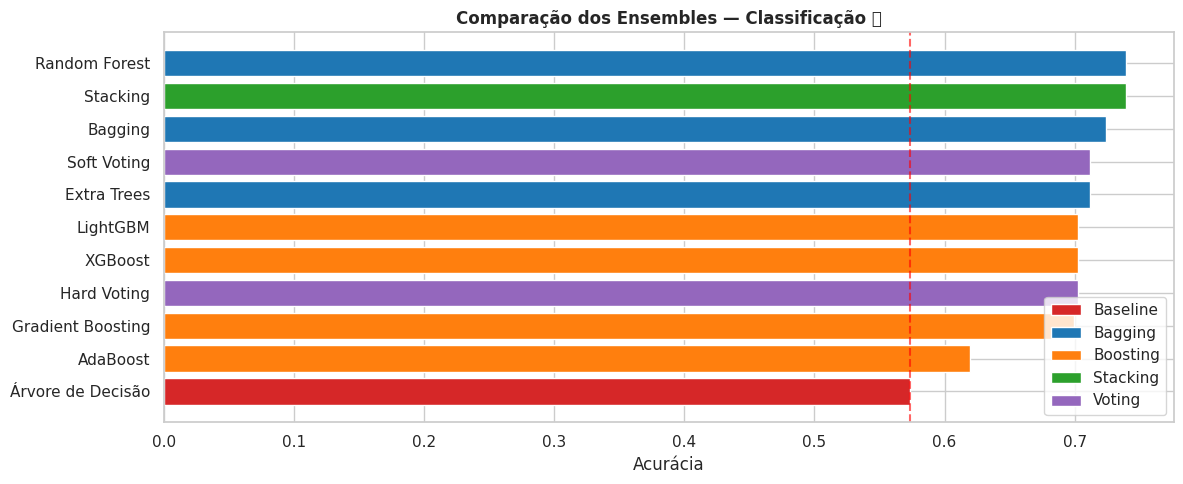

In [21]:
# ────────────────────────────────────────────────────────────
#  7.1 Ranking — Classificação
# ────────────────────────────────────────────────────────────
resultados_clf = pd.DataFrame({
    'Modelo': [
        'Árvore de Decisão',
        'Bagging',
        'Random Forest',
        'Extra Trees',
        'AdaBoost',
        'Gradient Boosting',
        'XGBoost',
        'LightGBM',
        'Stacking',
        'Hard Voting',
        'Soft Voting',
    ],
    'Categoria': [
        'Baseline',
        'Bagging', 'Bagging', 'Bagging',
        'Boosting', 'Boosting', 'Boosting', 'Boosting',
        'Stacking',
        'Voting', 'Voting',
    ],
    'Acurácia': [
        acc_arvore, acc_bag, acc_rf, acc_et,
        acc_ada, acc_gb, acc_xgb, acc_lgbm,
        acc_stk, acc_vh, acc_vs
    ]
}).sort_values('Acurácia', ascending=False).reset_index(drop=True)

resultados_clf.index += 1
print('🏆 Ranking — Classificação (por Acurácia):')
print(resultados_clf.to_string())

# Gráfico
cores_cat = {
    'Baseline': '#d62728',
    'Bagging': '#1f77b4',
    'Boosting': '#ff7f0e',
    'Stacking': '#2ca02c',
    'Voting': '#9467bd'
}
cores = resultados_clf['Categoria'].map(cores_cat)

plt.figure(figsize=(12, 5))
bars = plt.barh(resultados_clf['Modelo'][::-1],
                resultados_clf['Acurácia'][::-1],
                color=cores[::-1], edgecolor='white')
plt.axvline(acc_arvore, ls='--', color='red', alpha=0.6, label='Baseline')
plt.xlabel('Acurácia')
plt.title('Comparação dos Ensembles — Classificação 🍷', fontweight='bold')

# Legenda de categorias
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=k) for k, c in cores_cat.items()]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

🏆 Ranking — Regressão (por RMSE, menor é melhor):
              Modelo Categoria    RMSE      R²
1      Random Forest   Bagging  0.5968  0.4368
2           Stacking  Stacking  0.5989  0.4328
3             Voting    Voting  0.6033  0.4245
4           AdaBoost  Boosting  0.6186  0.3948
5            XGBoost  Boosting  0.6213  0.3895
6  Gradient Boosting  Boosting  0.6231  0.3860
7           LightGBM  Boosting  0.6295  0.3734


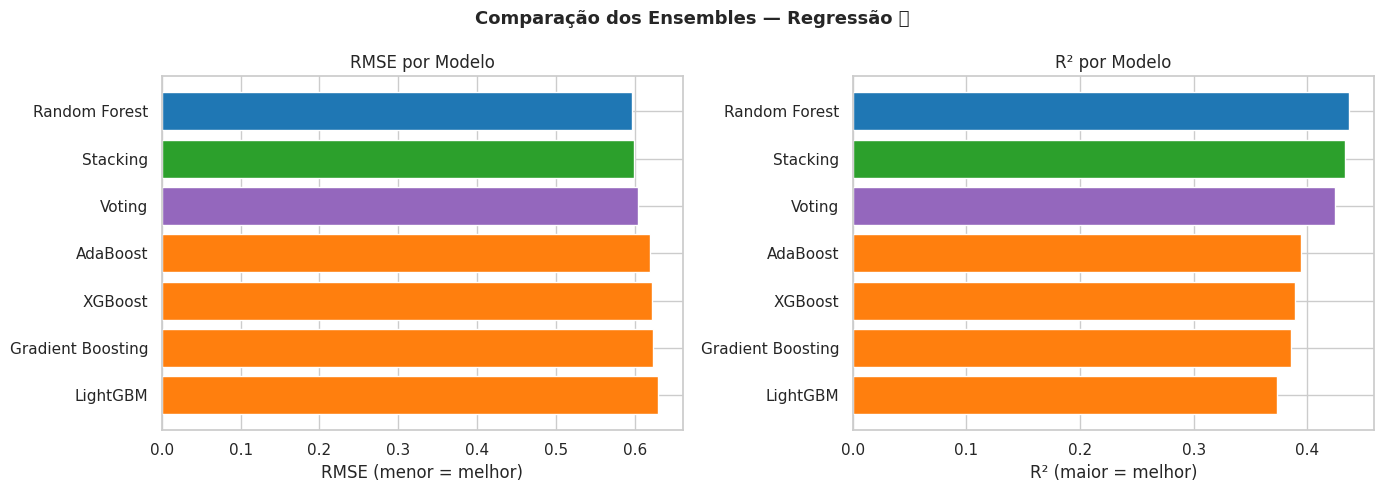

In [22]:
# ────────────────────────────────────────────────────────────
#  7.2 Ranking — Regressão
# ────────────────────────────────────────────────────────────
# Coletando métricas dos modelos de regressão já treinados
def metricas_reg(modelo, X_test, y_test):
    pred = modelo.predict(X_test)
    return {
        'RMSE': round(np.sqrt(mean_squared_error(y_test, pred)), 4),
        'R²':   round(r2_score(y_test, pred), 4)
    }

rows_reg = []
modelos_treinados = {
    'Random Forest': (rf_reg, 'Bagging'),
    'AdaBoost': (modelos_reg['AdaBoost'], 'Boosting'),
    'Gradient Boosting': (modelos_reg['Gradient Boosting'], 'Boosting'),
    'XGBoost': (modelos_reg['XGBoost'], 'Boosting'),
    'LightGBM': (modelos_reg['LightGBM'], 'Boosting'),
    'Stacking': (stacking_reg, 'Stacking'),
    'Voting': (voting_reg, 'Voting'),
}

for nome, (modelo, cat) in modelos_treinados.items():
    m = metricas_reg(modelo, X_test_s, y_test_r)
    rows_reg.append({'Modelo': nome, 'Categoria': cat, **m})

df_reg = pd.DataFrame(rows_reg).sort_values('RMSE').reset_index(drop=True)
df_reg.index += 1

print('🏆 Ranking — Regressão (por RMSE, menor é melhor):')
print(df_reg.to_string())

# Gráfico duplo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cores_r = df_reg['Categoria'].map(cores_cat)
ax1.barh(df_reg['Modelo'][::-1], df_reg['RMSE'][::-1], color=cores_r[::-1], edgecolor='white')
ax1.set_xlabel('RMSE (menor = melhor)')
ax1.set_title('RMSE por Modelo')

ax2.barh(df_reg['Modelo'][::-1], df_reg['R²'][::-1], color=cores_r[::-1], edgecolor='white')
ax2.set_xlabel('R² (maior = melhor)')
ax2.set_title('R² por Modelo')

plt.suptitle('Comparação dos Ensembles — Regressão 🍷', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

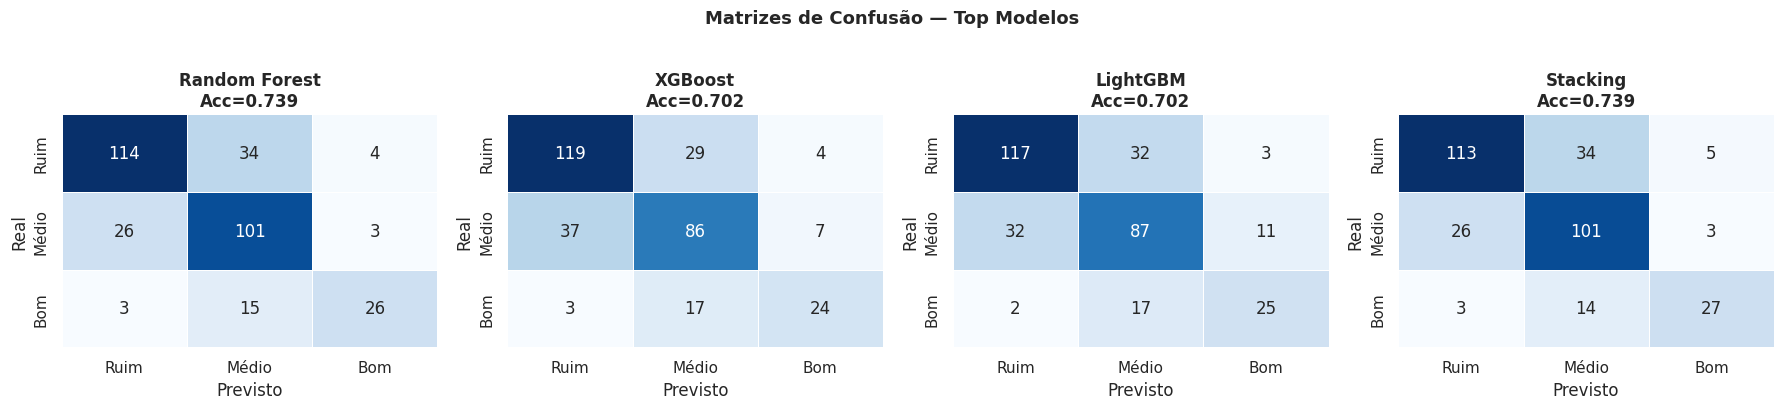

In [ ]:
# ────────────────────────────────────────────────────────────
#  7.3 Matrizes de Confusão — melhores modelos
# ────────────────────────────────────────────────────────────
melhores = [
    ('Random Forest', rf_clf),
    ('XGBoost', xgb_clf),
    ('LightGBM', lgbm_clf),
    ('Stacking', stacking_clf),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
rotulos_str = ['Ruim', 'Médio', 'Bom']

for ax, (nome, modelo) in zip(axes, melhores):
    cm = confusion_matrix(y_test_c, modelo.predict(X_test_cs))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=rotulos_str, yticklabels=rotulos_str,
                cmap='Blues', linewidths=0.5, cbar=False)
    acc = accuracy_score(y_test_c, modelo.predict(X_test_cs))
    ax.set_title(f'{nome}\nAcc={acc:.3f}', fontweight='bold')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de Confusão — Top Modelos', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Quando Usar Cada Técnica? 📌

| Técnica | Reduz | Ideal para | Cuidados |
|---------|-------|------------|----------|
| **Bagging** | Variância | Modelos instáveis (árvores profundas) | Pouco ganho com modelos estáveis |
| **Random Forest** | Variância | Uso geral — rápido e robusto | Menos interpretável que árvore única |
| **AdaBoost** | Viés | Modelos fracos (stumps) | Sensível a outliers e ruído |
| **Gradient Boosting** | Viés | Dados tabulares em geral | Mais lento; ajuste fino necessário |
| **XGBoost / LightGBM** | Viés | Competições / produção | Muitos hiperparâmetros |
| **Stacking** | Viés + Variância | Maximizar performance | Custo computacional alto |
| **Voting** | Variância | Combinar modelos diversificados | Modelos devem ser independentes |

---

## 9. 🔬 Exercícios Propostos

1. **Bagging:** Varie `n_estimators` de 10 a 500 e plote a acurácia no teste. Existe um ponto de saturação?

2. **XGBoost:** Ajuste `learning_rate` e `max_depth`. Como eles interagem?

3. **Stacking com passthrough=True:** Inclua as features originais no meta-modelo. Melhora?

4. **Variáveis sintéticas:** A feature `temp_fermentacao` foi criada com ruído puro. O Random Forest conseguiu identificar que ela é pouco importante?

5. **Regressão vs Classificação:** Compare os R² dos modelos. Faz sentido a ordenação ser similar entre regressão e classificação?

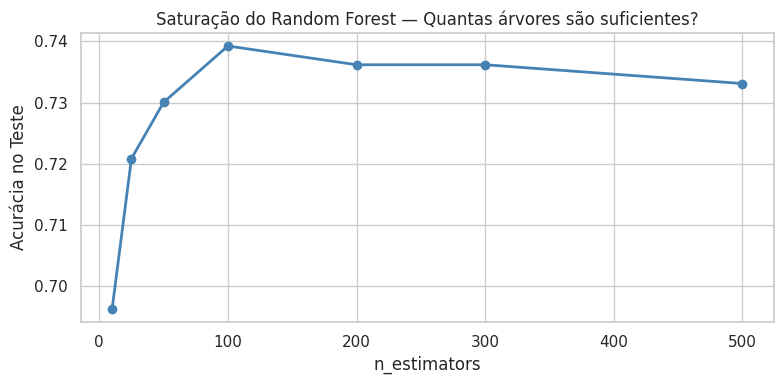

In [ ]:
# 🔬 Espaço para exercícios
# Experimente aqui!

# Exercício 1 — Saturação do Bagging
n_vals = [10, 25, 50, 100, 200, 300, 500]
accs_n = []

for n in n_vals:
    m = RandomForestClassifier(n_estimators=n, random_state=SEED, n_jobs=-1)
    m.fit(X_train_cs, y_train_c)
    accs_n.append(accuracy_score(y_test_c, m.predict(X_test_cs)))

plt.figure(figsize=(8, 4))
plt.plot(n_vals, accs_n, 'o-', color='steelblue', lw=2)
plt.xlabel('n_estimators')
plt.ylabel('Acurácia no Teste')
plt.title('Saturação do Random Forest — Quantas árvores são suficientes?')
plt.grid(True)
plt.tight_layout()
plt.show()

---
## 📚 Referências

- Breiman, L. (1996). Bagging Predictors. *Machine Learning*.
- Freund & Schapire (1997). A Decision-Theoretic Generalization of On-Line Learning — AdaBoost.
- Friedman (2001). Greedy Function Approximation — Gradient Boosting.
- Chen & Guestrin (2016). XGBoost: A Scalable Tree Boosting System.
- Ke et al. (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree.
- Scikit-learn: https://scikit-learn.org/stable/ensemble
- UCI Wine Quality Dataset: https://archive.ics.uci.edu/ml/datasets/wine+quality

---
*Notebook elaborado para o Curso de Machine Learning — Aula de Ensemble Learning*